# Solving "Titanic - Machine Learning from Disaster", from Kaggle website.

* **Fisrt step:** Reading all Datasets. There are two Datasets, the **"train"** and **"test"**, they will be used to train, and after the model is trained, the test set will be uset to evaluate its accuracy.


In [13]:
import pandas as pd

df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

print("=== FIRST 5 LINES ===")
display(df_train.head())

# these lines above are just to inspect the training dataset, to identify missing data.
print("\n'x-ray' from train dataset\n")
display(df_train.info())

=== FIRST 5 LINES ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



'x-ray' from train dataset

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

* **Second step:** Clean the dataset and determine which columns are useful fot the model.

In [14]:
# creating a new variable with same data, to manipulate and not modify the original dataset
clean_train = df_train.copy()
clean_test = df_test.copy()

# removing columns what are considered unsuitable to training model
columns_removing = ['Cabin', 'Name', 'Ticket', 'PassengerId']
clean_train = clean_train.drop(columns=columns_removing)
clean_test = clean_test.drop(columns=columns_removing)

# getting the median from 'age' and filling missing values at train and test datasets
age_median = clean_train['Age'].median()
clean_train['Age'] = clean_train['Age'].fillna(age_median)
clean_test['Age'] = clean_test['Age'].fillna(age_median)

# at embarked the mostly data are 'S'
clean_train['Embarked'] = clean_train['Embarked'].fillna('S')
clean_test['Embarked'] = clean_test['Embarked'].fillna('S')

# getting median from 'fare' and filling missing values
fare_median = clean_train['Fare'].median()
clean_train['Fare'] = clean_train['Fare'].fillna(fare_median)
clean_test['Fare'] = clean_test['Fare'].fillna(fare_median)

# Now,in the 'Sex' columns, i will replace male with 0 and female with 1
clean_train['Sex'] = clean_train['Sex'].map({'male': 0, 'female': 1})
clean_test['Sex'] = clean_test['Sex'].map({'male': 0, 'female': 1})

# And now, in the 'Embarked' columns, i will replace S with 0 and Q with 1
clean_train['Embarked'] = clean_train['Embarked'].map({'S': 0,'C': 1 ,'Q': 2})
clean_test['Embarked'] = clean_test['Embarked'].map({'S': 0,'C': 1, 'Q': 2})

# To verify if datasets are with useful data to train the model, i will use .info() function at cleaned copies dataset to check.
clean_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


* **3 step:** Train the Random Forest model.

In [15]:
from sklearn.ensemble import RandomForestClassifier

# saving the right answers as a var called 'y_train' in a separated array
y_train = clean_train['Survived']
# excluding the 'y_train' var from cleaned dataset
X_train = clean_train.drop(columns=['Survived']) # represents all columns, except Survived column

# how in test the column 'Survived' is empty...
X_test = clean_test

# 'n_estimators' means how much diferent decisions in binary tree will be taken
model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Initializating train...")

# the machine will learn in this step, with 'fit()' function
model.fit(X_train, y_train)

prevision = model.predict(X_test)

Initializating train...


--- TABELA ATUALIZADA ---


,PassengerId,Survived,Sex
0,892,0,male
1,893,0,female
2,894,0,male
3,895,1,male
4,896,0,female


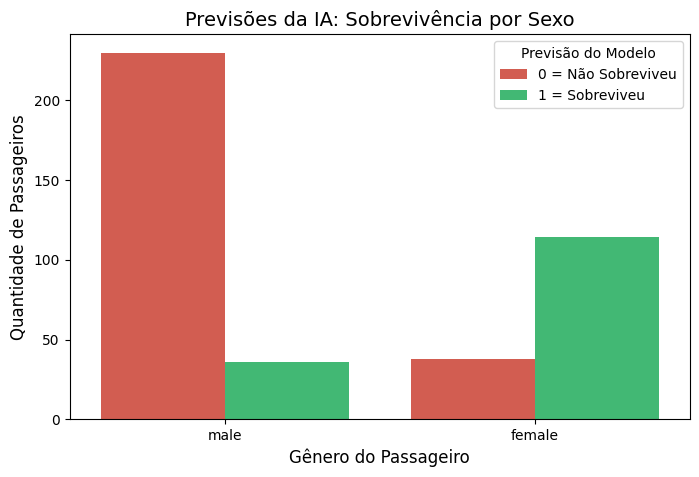

In [21]:
# 1. Puxando a coluna 'Sex' original para a nossa tabela de resultados
# Usamos o df_teste porque ele tem os nomes 'male' e 'female' escritos (fica mais bonito no gráfico)
resultados['Sex'] = df_test['Sex']

# 2. Exibindo como ficou a tabela nova
print("--- TABELA ATUALIZADA ---")
display(resultados.head())

# 3. Gerando o Gráfico Comparativo
plt.figure(figsize=(8, 5))

# A mágica do Seaborn: o 'x' separa as colunas por Sexo, e o 'hue' pinta elas dependendo se sobreviveu ou não!
sns.countplot(data=resultados, x='Sex', hue='Survived', palette=['#e74c3c', '#2ecc71'])

# Deixando o gráfico com cara de profissional
plt.title('Previsões da IA: Sobrevivência por Sexo', fontsize=14)
plt.xlabel('Gênero do Passageiro', fontsize=12)
plt.ylabel('Quantidade de Passageiros', fontsize=12)

# Arrumando a legenda que fica no canto
plt.legend(title='Previsão do Modelo', labels=['0 = Não Sobreviveu', '1 = Sobreviveu'])

# Exibindo o resultado final
plt.show()